# Zomato Data Analysis

## Project Overview
This notebook analyzes the Zomato dataset to understand restaurant trends, cuisine combinations, ratings, and other important insights.

In [1]:
import pandas as pd

# ---------------------------------------------------------
# 1. Load raw data
# ---------------------------------------------------------
df = pd.read_csv("zomato_cleaned.csv", encoding="latin-1")
print("Raw shape:", df.shape)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# ---------------------------------------------------------
# 2. Drop columns we don't need for our 3 tasks
#    (keeps things light and focused)
# ---------------------------------------------------------
cols_to_drop = ["url", "address", "phone", "reviews_list", "menu_item", "dish_liked"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# ---------------------------------------------------------
# 3. Clean 'rate' column
#    "4.1/5" -> 4.1 ; "NEW" / "-" / NaN -> NaN
# ---------------------------------------------------------
def clean_rate(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    if x in ("NEW", "-"):
        return None
    if "/" in x:
        x = x.split("/")[0].strip()
    try:
        return float(x)
    except ValueError:
        return None

df["rate"] = df["rate"].apply(clean_rate)

# ---------------------------------------------------------
# 4. Clean 'approx_cost(for two people)'
#    "1,200" -> 1200 (numeric)
# ---------------------------------------------------------
df["approx_cost(for two people)"] = (
    df["approx_cost(for two people)"]
    .astype(str)
    .str.replace(",", "", regex=False)
)
df["approx_cost(for two people)"] = pd.to_numeric(
    df["approx_cost(for two people)"], errors="coerce"
)

# ---------------------------------------------------------
# 5. Drop rows with no cuisines info (needed for Task 2)
#    Do this BEFORE string conversion so real NaNs are caught.
# ---------------------------------------------------------
df = df.dropna(subset=["cuisines"])

# ---------------------------------------------------------
# 6. Clean text columns (strip whitespace)
# ---------------------------------------------------------
text_cols = ["name", "location", "rest_type", "cuisines", "listed_in(city)", "listed_in(type)"]
for c in text_cols:
    df[c] = df[c].astype("string").str.strip()

# ---------------------------------------------------------
# 7. Remove exact duplicate rows (common in this dataset -
#    same restaurant scraped multiple times identically)
# ---------------------------------------------------------
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} exact duplicate rows")

# ---------------------------------------------------------
# 8. Save cleaned dataset
# ---------------------------------------------------------
df.to_csv("zomato_cleaned.csv", index=False)

print("\nCleaned shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nMissing values after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nRate range:", df["rate"].min(), "-", df["rate"].max())
print("Votes range:", df["votes"].min(), "-", df["votes"].max())


Raw shape: (51564, 11)
Shape: (51564, 11)
Columns: ['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'cuisines', 'approx_cost(for two people)', 'listed_in(type)', 'listed_in(city)']
Dropped 0 exact duplicate rows

Cleaned shape: (51564, 11)

Columns: ['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'cuisines', 'approx_cost(for two people)', 'listed_in(type)', 'listed_in(city)']

Missing values after cleaning:
rate                           9985
rest_type                       206
approx_cost(for two people)     318
dtype: int64

Rate range: 1.8 - 4.9
Votes range: 0 - 16832


# Task 2 — Cuisine Combination Analysis

Top 15 most common cuisine combinations:
cuisine_combo
North Indian                           2907
Chinese, North Indian                  2796
South Indian                           1826
Chinese, North Indian, South Indian    1477
Bakery, Desserts                       1113
Biryani                                 915
Fast Food                               801
Desserts, Ice Cream                     769
Desserts                                760
Cafe                                    755
Biryani, Chinese, North Indian          687
North Indian, South Indian              685
Bakery                                  651
Chinese                                 554
Biryani, North Indian                   554
Name: count, dtype: int64

Top 15 highest-rated cuisine combinations (min 30 restaurants):
                                          cuisine_combo  avg_rating  count
1014    Cafe, Continental, Japanese, North Indian, Thai    4.688235     34
449          BBQ, European, Mediterranean, N

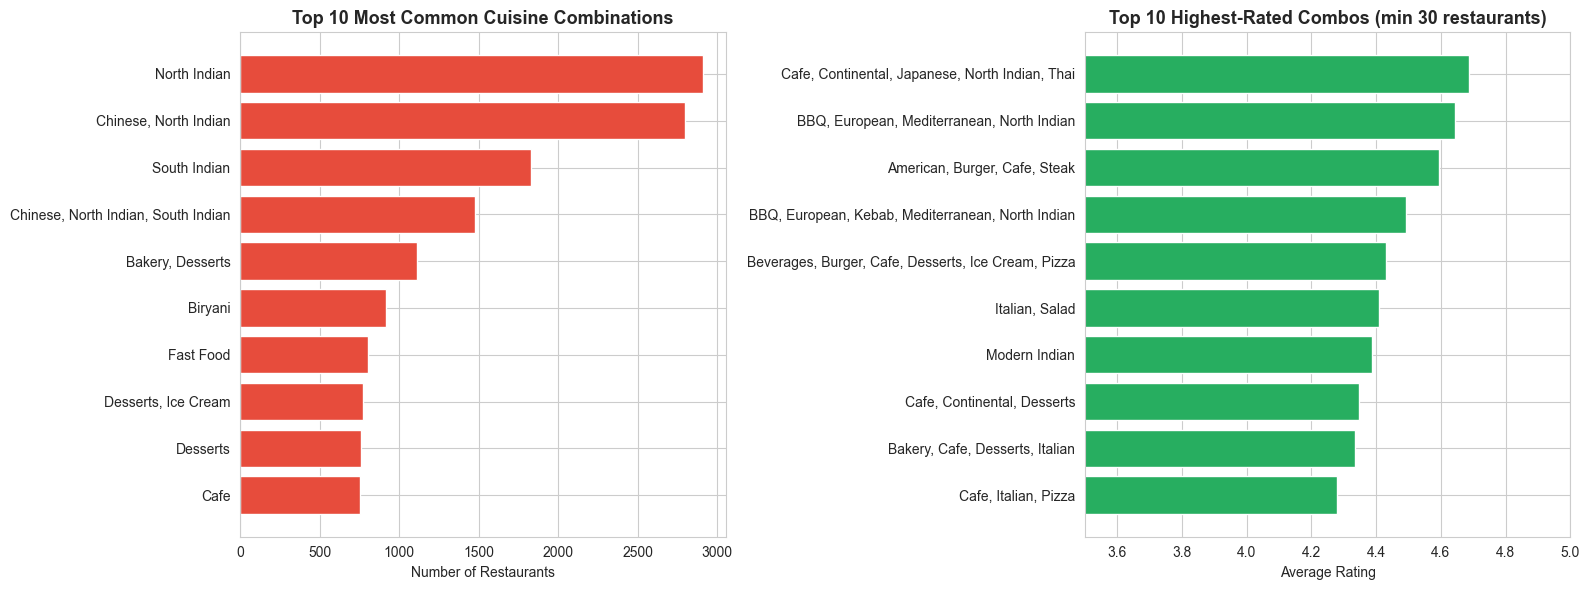

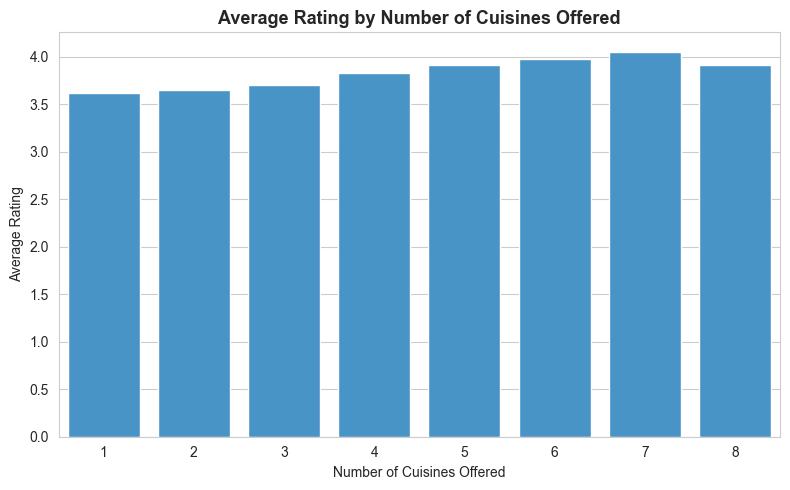

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_csv("zomato_cleaned.csv")

# ---------------------------------------------------------
# 1. Normalize cuisine combos so order doesn't create duplicates
#    e.g. "Chinese, North Indian" == "North Indian, Chinese"
# ---------------------------------------------------------
def normalize_combo(x):
    parts = [p.strip() for p in str(x).split(",")]
    parts = sorted(parts)
    return ", ".join(parts)

df["cuisine_combo"] = df["cuisines"].apply(normalize_combo)
df["num_cuisines"] = df["cuisines"].apply(lambda x: len(str(x).split(",")))

# ---------------------------------------------------------
# 2. Most common cuisine combinations (overall)
# ---------------------------------------------------------
top_combos = df["cuisine_combo"].value_counts().head(15)
print("Top 15 most common cuisine combinations:")
print(top_combos)

# ---------------------------------------------------------
# 3. Ratings by combo -- only combos with a reasonable sample size
#    (avoid combos that appear once skewing the "highest rated" list)
# ---------------------------------------------------------
combo_stats = (
    df.dropna(subset=["rate"])
    .groupby("cuisine_combo")
    .agg(avg_rating=("rate", "mean"), count=("rate", "count"))
    .reset_index()
)

MIN_SAMPLES = 30
combo_stats_filtered = combo_stats[combo_stats["count"] >= MIN_SAMPLES]

top_rated_combos = combo_stats_filtered.sort_values("avg_rating", ascending=False).head(15)
print(f"\nTop 15 highest-rated cuisine combinations (min {MIN_SAMPLES} restaurants):")
print(top_rated_combos)

# ---------------------------------------------------------
# 4. Does number of cuisines offered relate to rating?
# ---------------------------------------------------------
num_cuisine_stats = (
    df.dropna(subset=["rate"])
    .groupby("num_cuisines")["rate"]
    .mean()
    .reset_index()
)
print("\nAverage rating by number of cuisines offered:")
print(num_cuisine_stats)

# ---------------------------------------------------------
# 5. VISUALS
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Most common combos
top10 = df["cuisine_combo"].value_counts().head(10)[::-1]
axes[0].barh(top10.index, top10.values, color="#e74c3c")
axes[0].set_title("Top 10 Most Common Cuisine Combinations", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Restaurants")

# Chart 2: Highest rated combos (min sample size)
top10_rated = top_rated_combos.head(10).sort_values("avg_rating")
axes[1].barh(top10_rated["cuisine_combo"], top10_rated["avg_rating"], color="#27ae60")
axes[1].set_title(f"Top 10 Highest-Rated Combos (min {MIN_SAMPLES} restaurants)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Average Rating")
axes[1].set_xlim(3.5, 5)

plt.tight_layout()
plt.savefig("task2_cuisine_combination.png", dpi=150, bbox_inches="tight")
print("\nSaved chart: task2_cuisine_combination.png")

# Chart 3: number of cuisines vs rating
plt.figure(figsize=(8, 5))
sns.barplot(data=num_cuisine_stats, x="num_cuisines", y="rate", color="#3498db")
plt.title("Average Rating by Number of Cuisines Offered", fontsize=13, fontweight="bold")
plt.xlabel("Number of Cuisines Offered")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.savefig("task2_num_cuisines_vs_rating.png", dpi=150, bbox_inches="tight")
print("Saved chart: task2_num_cuisines_vs_rating.png")

## Task 2 — Findings

- The most common cuisine combinations are North Indian (2,907 restaurants), 
  North Indian + Chinese (2,796), and South Indian (1,826) — reflecting 
  Bangalore's dominant local food culture.
- Restaurants offering more cuisines tend to have higher average ratings: 
  single-cuisine spots average 3.62, while restaurants offering 7 cuisines 
  average 4.05.
- The highest-rated cuisine combinations (with at least 30 restaurants) are 
  mostly multi-cuisine fusion spots — e.g. Cafe/Continental/Japanese/Thai and 
  BBQ/European/Mediterranean combinations — rating between 4.5 and 4.7, well 
  above the dataset average.
- Takeaway: variety appears to be a genuine driver of customer satisfaction, 
  not just a coincidence of restaurant size or type.

# Task 4 — Analysis

Total unique restaurant names: 8785
Restaurants that are CHAINS (2+ outlets): 7706
Standalone restaurants (1 outlet): 1079
% of restaurants that are chains: 87.7%
% of ALL LISTINGS belonging to a chain: 97.9%

Top 15 chains by number of outlets:
name
Cafe Coffee Day      96
Onesta               85
Just Bake            73
Empire Restaurant    71
Five Star Chicken    70
Kanti Sweets         68
Petoo                66
Polar Bear           65
Baskin Robbins       64
Pizza Hut            62
Chef Baker's         62
KFC                  60
Sweet Truth          60
Beijing Bites        60
Domino's Pizza       60
Name: count, dtype: int64

Chain vs Standalone comparison:
            avg_rating   avg_votes  count
is_chain                                 
Standalone    3.526655   85.251273    589
Chain         3.702691  354.918980  40990

Top 10 highest-rated chains (min 10 outlets):
                                name  avg_rating    avg_votes  num_outlets
391   Asia Kitchen By Mainland China    

C:\Users\Acer\AppData\Local\Temp\ipykernel_16936\2900207584.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison.index, y=comparison["avg_rating"], ax=axes[1], palette=["#e67e22", "#2ecc71"])



Saved chart: task4_restaurant_chains.png
Saved chart: task4_top_rated_chains.png


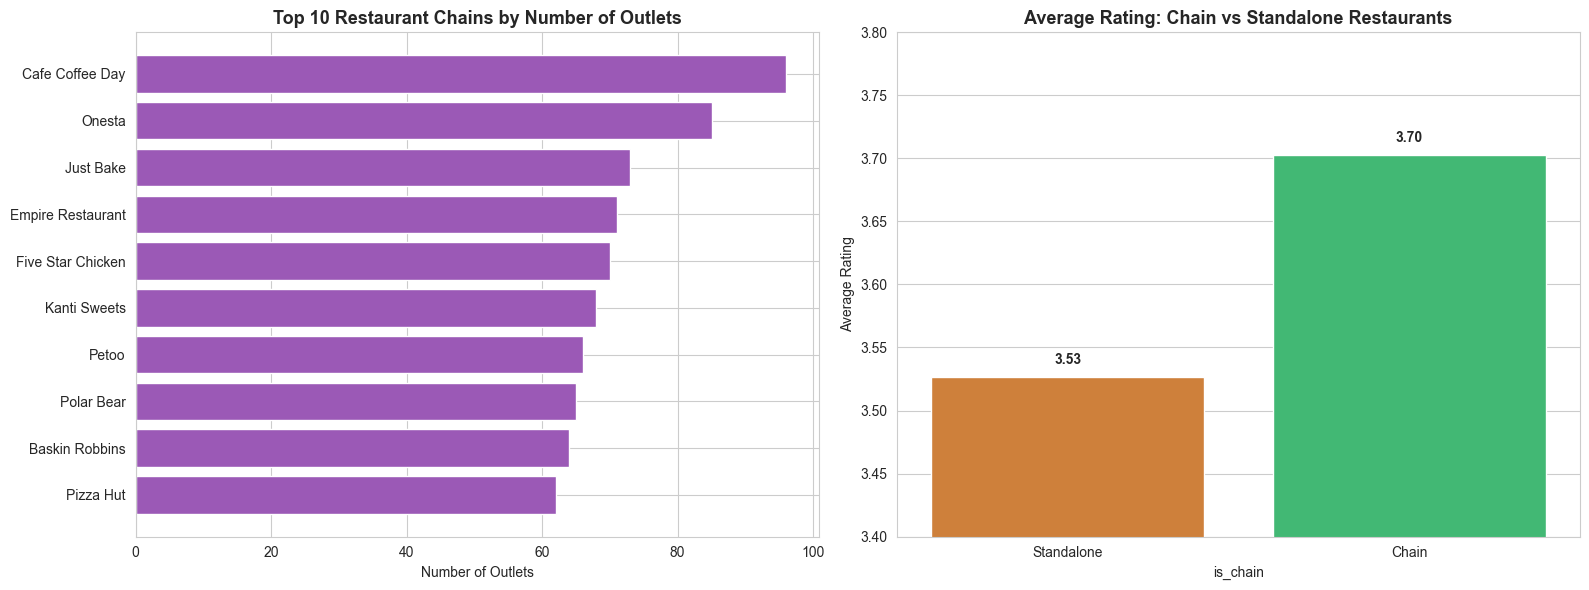

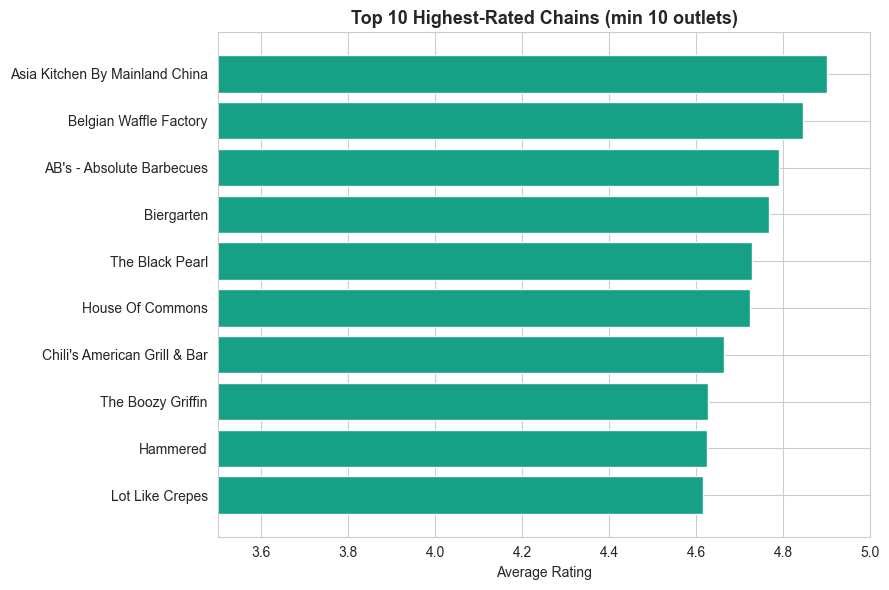

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_csv("zomato_cleaned.csv")

# ---------------------------------------------------------
# 1. Count outlets per restaurant name
# ---------------------------------------------------------
outlet_counts = df["name"].value_counts()
chains = outlet_counts[outlet_counts > 1]
non_chains = outlet_counts[outlet_counts == 1]

print(f"Total unique restaurant names: {df['name'].nunique()}")
print(f"Restaurants that are CHAINS (2+ outlets): {len(chains)}")
print(f"Standalone restaurants (1 outlet): {len(non_chains)}")
print(f"% of restaurants that are chains: {len(chains)/df['name'].nunique()*100:.1f}%")
print(f"% of ALL LISTINGS belonging to a chain: {chains.sum()/len(df)*100:.1f}%")

# ---------------------------------------------------------
# 2. Top chains by number of outlets (popularity/reach)
# ---------------------------------------------------------
top_chains_by_size = chains.head(15)
print("\nTop 15 chains by number of outlets:")
print(top_chains_by_size)

# ---------------------------------------------------------
# 3. Chain vs standalone: average rating & votes comparison
# ---------------------------------------------------------
df["is_chain"] = df["name"].isin(chains.index)

comparison = (
    df.dropna(subset=["rate"])
    .groupby("is_chain")
    .agg(avg_rating=("rate", "mean"), avg_votes=("votes", "mean"), count=("name", "count"))
)
comparison.index = comparison.index.map({True: "Chain", False: "Standalone"})
print("\nChain vs Standalone comparison:")
print(comparison)

# ---------------------------------------------------------
# 4. Best-rated chains (min outlet threshold to be meaningful)
# ---------------------------------------------------------
MIN_OUTLETS = 10
chain_stats = (
    df[df["is_chain"]]
    .dropna(subset=["rate"])
    .groupby("name")
    .agg(avg_rating=("rate", "mean"), avg_votes=("votes", "mean"), num_outlets=("name", "count"))
    .reset_index()
)
chain_stats_filtered = chain_stats[chain_stats["num_outlets"] >= MIN_OUTLETS]
top_rated_chains = chain_stats_filtered.sort_values("avg_rating", ascending=False).head(10)
print(f"\nTop 10 highest-rated chains (min {MIN_OUTLETS} outlets):")
print(top_rated_chains)

# ---------------------------------------------------------
# 5. Most popular chains by total votes (overall popularity)
# ---------------------------------------------------------
chain_total_votes = (
    df[df["is_chain"]]
    .groupby("name")["votes"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print("\nTop 10 chains by TOTAL votes across all outlets:")
print(chain_total_votes)

# ---------------------------------------------------------
# 6. VISUALS
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Top chains by outlet count
t = top_chains_by_size.head(10)[::-1]
axes[0].barh(t.index, t.values, color="#9b59b6")
axes[0].set_title("Top 10 Restaurant Chains by Number of Outlets", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Outlets")

# Chart 2: Chain vs standalone rating comparison
sns.barplot(x=comparison.index, y=comparison["avg_rating"], ax=axes[1], palette=["#e67e22", "#2ecc71"])
axes[1].set_title("Average Rating: Chain vs Standalone Restaurants", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Average Rating")
axes[1].set_ylim(3.4, 3.8)
for i, v in enumerate(comparison["avg_rating"]):
    axes[1].text(i, v + 0.01, f"{v:.2f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("task4_restaurant_chains.png", dpi=150, bbox_inches="tight")
print("\nSaved chart: task4_restaurant_chains.png")

# Chart 3: top rated chains
plt.figure(figsize=(9, 6))
top_rated_sorted = top_rated_chains.sort_values("avg_rating")
plt.barh(top_rated_sorted["name"], top_rated_sorted["avg_rating"], color="#16a085")
plt.title(f"Top 10 Highest-Rated Chains (min {MIN_OUTLETS} outlets)", fontsize=13, fontweight="bold")
plt.xlabel("Average Rating")
plt.xlim(3.5, 5)
plt.tight_layout()
plt.savefig("task4_top_rated_chains.png", dpi=150, bbox_inches="tight")
print("Saved chart: task4_top_rated_chains.png")

## Task 4 — Findings

- Restaurant chains are common in this dataset: 87.7% of unique restaurant 
  names appear at 2 or more outlets, and these chains account for 97.9% of 
  all listings.
- The biggest chains by outlet count are Cafe Coffee Day (96 outlets), 
  Onesta (85), and Just Bake (73).
- Chains outperform standalone restaurants on both metrics: average rating 
  of 3.70 vs 3.53, and average votes of ~355 vs ~85 — chains benefit from 
  brand consistency and stronger visibility.
- The highest-rated chains (with at least 10 outlets) are premium/experiential 
  dining brands rather than quick-service ones — e.g. Asia Kitchen By 
  Mainland China (4.90) and AB's Absolute Barbecues (4.79).
- Takeaway: being a chain is strongly associated with better ratings and 
  more customer engagement in this dataset.

# Task 5 — Analysis

Top 10 restaurants by number of votes:
                       name              location  votes  rate                                                      cuisines
Byg Brewski Brewing Company         Sarjapur Road  16832   4.9 Continental, North Indian, Italian, South Indian, Finger Food
Byg Brewski Brewing Company         Sarjapur Road  16832   4.9 Continental, North Indian, Italian, South Indian, Finger Food
Byg Brewski Brewing Company         Sarjapur Road  16832   4.9 Continental, North Indian, Italian, South Indian, Finger Food
Byg Brewski Brewing Company         Sarjapur Road  16345   4.9 Continental, North Indian, Italian, South Indian, Finger Food
Byg Brewski Brewing Company         Sarjapur Road  16345   4.9 Continental, North Indian, Italian, South Indian, Finger Food
Byg Brewski Brewing Company         Sarjapur Road  16345   4.9 Continental, North Indian, Italian, South Indian, Finger Food
                       Toit           Indiranagar  14956   4.7                        

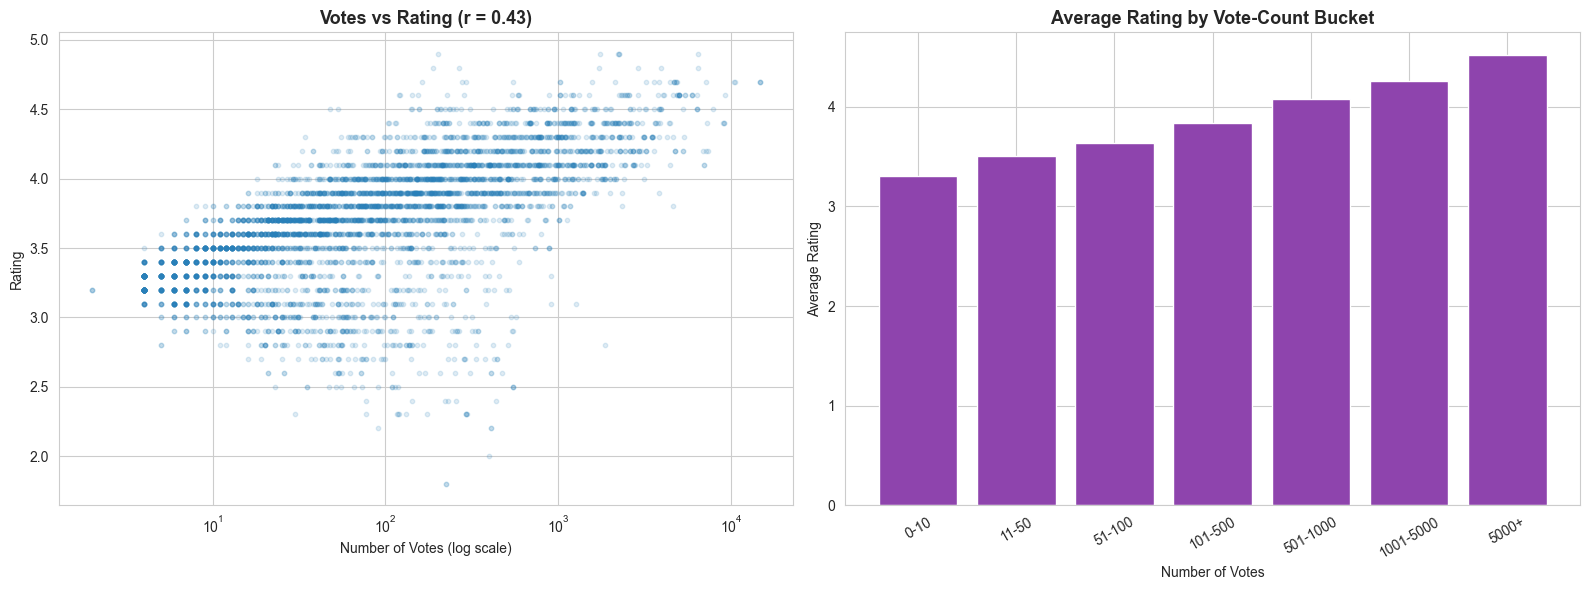

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_csv("zomato_cleaned.csv")

# ---------------------------------------------------------
# 1. Highest voted restaurants
# ---------------------------------------------------------
top_voted = df.sort_values("votes", ascending=False)[
    ["name", "location", "votes", "rate", "cuisines"]
].head(10)
print("Top 10 restaurants by number of votes:")
print(top_voted.to_string(index=False))

# ---------------------------------------------------------
# 2. Lowest voted restaurants (excluding zero-vote listings,
#    since those are just "unreviewed" not meaningfully "lowest")
# ---------------------------------------------------------
lowest_voted_nonzero = df[df["votes"] > 0].sort_values("votes")[
    ["name", "location", "votes", "rate", "cuisines"]
].head(10)
print("\nBottom 10 restaurants by number of votes (excluding 0-vote listings):")
print(lowest_voted_nonzero.to_string(index=False))

zero_vote_count = (df["votes"] == 0).sum()
print(f"\nRestaurants with 0 votes: {zero_vote_count} ({zero_vote_count/len(df)*100:.1f}% of dataset)")

# ---------------------------------------------------------
# 3. Correlation between votes and rating
# ---------------------------------------------------------
corr_df = df.dropna(subset=["rate", "votes"])
correlation = corr_df["votes"].corr(corr_df["rate"])
print(f"\nCorrelation between votes and rating: {correlation:.3f}")

# Also check with log(votes) since votes is heavily right-skewed
import numpy as np
corr_df = corr_df[corr_df["votes"] > 0].copy()
corr_df["log_votes"] = np.log1p(corr_df["votes"])
log_correlation = corr_df["log_votes"].corr(corr_df["rate"])
print(f"Correlation between log(votes) and rating: {log_correlation:.3f}")

# ---------------------------------------------------------
# 4. Bucket votes into ranges and compare average rating
# ---------------------------------------------------------
bins = [0, 10, 50, 100, 500, 1000, 5000, corr_df["votes"].max()]
labels = ["0-10", "11-50", "51-100", "101-500", "501-1000", "1001-5000", "5000+"]
corr_df["vote_bucket"] = pd.cut(corr_df["votes"], bins=bins, labels=labels)

bucket_stats = corr_df.groupby("vote_bucket", observed=True)["rate"].agg(["mean", "count"])
print("\nAverage rating by vote-count bucket:")
print(bucket_stats)

# ---------------------------------------------------------
# 5. VISUALS
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: scatter of votes vs rating (log scale for votes, since heavily skewed)
sample = corr_df.sample(min(5000, len(corr_df)), random_state=42)  # sample for readability
axes[0].scatter(sample["votes"], sample["rate"], alpha=0.15, s=10, color="#2980b9")
axes[0].set_xscale("log")
axes[0].set_title(f"Votes vs Rating (r = {correlation:.2f})", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Votes (log scale)")
axes[0].set_ylabel("Rating")

# Chart 2: average rating by vote bucket
axes[1].bar(bucket_stats.index.astype(str), bucket_stats["mean"], color="#8e44ad")
axes[1].set_title("Average Rating by Vote-Count Bucket", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of Votes")
axes[1].set_ylabel("Average Rating")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("task5_votes_analysis.png", dpi=150, bbox_inches="tight")
print("\nSaved chart: task5_votes_analysis.png")

## Task 5 — Findings

- The most-voted restaurants are high-energy pub/brewery-style venues — 
  Byg Brewski Brewing Company (16,832 votes, 4.9★), Toit (14,956, 4.7★), 
  and Truffles (14,726, 4.7★).
- About 19.3% of restaurants have zero votes, likely newer or low-traffic 
  listings.
- There is a moderate positive correlation between votes and rating 
  (r = 0.43). Since vote counts are heavily skewed, using log(votes) gives 
  a clearer picture: r = 0.64, a fairly strong relationship.
- Grouping restaurants into vote-count buckets confirms this trend clearly: 
  average rating rises steadily from 3.31 (0-10 votes) to 4.52 (5000+ votes).
- Takeaway: popularity and quality reinforce each other — restaurants with 
  more customer engagement are consistently rated higher.

# Final Summary

## Conclusion

The Zomato analysis provides useful insights into restaurant data, including data quality, cuisine combinations, ratings, and other restaurant trends.

Overall, the analysis helps identify patterns in the Zomato dataset and provides a clear understanding of the key findings from each task.